# Tarang ECG Classifier v6 — Phase B: Retrain with INCART + 3-Class SV

**Team Ocelleon — IoT Challenge 2026**

## What Phase B changes vs Phase A

| Patch | What | Expected impact |
|-------|------|-----------------|
| **B1** | Add INCART train split (I01–I50) to Gate + SV training | Closes V generalization gap (INCART V F1: 0.23 → ~0.55+) |
| **B2** | Convert SV from binary (S/V) → 3-class (N/S/V) softmax | Fixes cascade S precision (S F1: 0.12 → ~0.45+) |
| **B3** | Build SV training set from Gate's routed population | SV learns to reject Gate false positives back to N |

## INCART split

- Train: I01–I50 (50 records, ~117K beats) → added to MIT-BIH train
- Test: I51–I75 (25 records, ~58K beats) → held-out cross-DB eval

## What stays the same from Phase A

- Window geometry (130 samples @ 250 Hz)
- `FORCE_SINGLE_LEAD=True`
- 7 RR features
- Gate CNN architecture
- AAMI beat mapping
- Threshold tuning on VAL, frozen on TEST

## Expected runtime

- Data loading: ~5 min (loads MIT-BIH + SVDB + INCART)
- Gate training (fine-tuned from Phase A weights): ~15-20 min
- SV training (3-class, from scratch): ~15-20 min
- Eval + cross-DB: ~3 min

**Total: ~40-50 minutes** on a typical GPU.

In [1]:
# === Cell 1 — imports + paths (same as Phase A) ============================
import os, json, subprocess, warnings
from collections import Counter

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import resample_poly

import tensorflow as tf
from tensorflow.keras import regularizers

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_curve, auc)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")

MITBIH_PATH = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset/mit-bih-arrhythmia-database-1.0.0'
SVDB_PATH   = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset/mit-bih-supraventricular-arrhythmia-database-1.0.0'
INCART_PATH = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset/incartdb'

OUTPUTS_DIR_PHASE_A   = 'outputs_v6_phaseA'   # ← Phase A Gate checkpoint (for warm-start)
OUTPUTS_DIR_PHASE_B   = 'outputs_v6_phaseB'
GATE_CHECKPOINT_A     = f'{OUTPUTS_DIR_PHASE_A}/tarang_gate_best.keras'
GATE_CHECKPOINT       = f'{OUTPUTS_DIR_PHASE_B}/tarang_gate_best.keras'
SV_CHECKPOINT         = f'{OUTPUTS_DIR_PHASE_B}/tarang_sv_best.keras'   # 3-class
os.makedirs(OUTPUTS_DIR_PHASE_B, exist_ok=True)

FS          = 250
WINDOW_PRE  = 65
WINDOW_POST = 65
WINDOW_LEN  = 130
FORCE_SINGLE_LEAD = True   # carry over from Phase A

# INCART split — train first 50, test last 25
INCART_TRAIN_RECORDS = [f'I{i:02d}' for i in range(1, 51)]
INCART_TEST_RECORDS  = [f'I{i:02d}' for i in range(51, 76)]

print(f"Phase B outputs dir: {OUTPUTS_DIR_PHASE_B}")
print(f"INCART train: {len(INCART_TRAIN_RECORDS)} records ({INCART_TRAIN_RECORDS[0]}..{INCART_TRAIN_RECORDS[-1]})")
print(f"INCART test : {len(INCART_TEST_RECORDS)} records ({INCART_TEST_RECORDS[0]}..{INCART_TEST_RECORDS[-1]})")
print(f"Phase A Gate warm-start: {GATE_CHECKPOINT_A}  (exists={os.path.exists(GATE_CHECKPOINT_A)})")

GPU memory growth enabled for 1 GPU(s)
Phase B outputs dir: outputs_v6_phaseB
INCART train: 50 records (I01..I50)
INCART test : 25 records (I51..I75)
Phase A Gate warm-start: outputs_v6_phaseA/tarang_gate_best.keras  (exists=True)


In [2]:
# === Cell 2 — AAMI mapping & MIT-BIH splits (same as Phase A) ==============
BEAT_MAP = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'V',
    '/': 'Q', 'f': 'Q', 'Q': 'Q',
}
CLASSES_TO_USE = ['N', 'V', 'S']

MITBIH_ALL_RECORDS = [
    100,101,102,103,104,105,106,107,108,109,
    111,112,113,114,115,116,117,118,119,121,
    122,123,124,200,201,202,203,205,207,208,
    209,210,212,213,214,215,217,219,220,221,
    222,223,228,230,231,232,233,234
]
MITBIH_TEST_RECORDS = [
    101,106,108,109,112,114,115,116,118,119,
    201,202,203,205,207,208,209,210,217,219,
    221,223,228,231,233,234
]
MITBIH_VAL_RECORDS   = [105, 124, 214, 220]
MITBIH_TRAIN_RECORDS = [r for r in MITBIH_ALL_RECORDS
                        if r not in MITBIH_TEST_RECORDS
                        and r not in MITBIH_VAL_RECORDS]

SVDB_RECORDS = [f'{i}' for i in range(800, 895)]

print(f"MIT-BIH train/val/test : {len(MITBIH_TRAIN_RECORDS)}/{len(MITBIH_VAL_RECORDS)}/{len(MITBIH_TEST_RECORDS)}")
print(f"SVDB                   : {len(SVDB_RECORDS)} records")
print(f"INCART train/test      : {len(INCART_TRAIN_RECORDS)}/{len(INCART_TEST_RECORDS)} records  ← B1 patch")

MIT-BIH train/val/test : 18/4/26
SVDB                   : 95 records
INCART train/test      : 50/25 records  ← B1 patch


In [3]:
# === Cell 3 — RR features + normalization (same as Phase A) ================
def rolling_window_normalize(signal, window_samples=7500):
    s    = pd.Series(signal.astype(np.float64))
    roll = s.rolling(window=window_samples, min_periods=1)
    mean = roll.mean()
    std  = roll.std(ddof=0).fillna(0).clip(lower=1e-8)
    return ((s - mean) / std).values.astype(np.float32)


def compute_rr_features(peaks, beat_idx):
    n = len(peaks)
    i = beat_idx
    prev_idx = max(0, i-1)
    next_idx = min(n-1, i+1)
    rr_prev  = (peaks[i]      - peaks[prev_idx]) / FS
    rr_next  = (peaks[next_idx] - peaks[i])      / FS
    rr_ratio = rr_prev / max(rr_next, 1e-4)

    lo = max(0, i-2); hi = min(n-1, i+2)
    local_rrs = np.diff(peaks[lo:hi+1]).astype(np.float32) / FS
    rr_mean_5 = float(np.mean(local_rrs)) if len(local_rrs) > 0 else rr_prev
    rr_std_5  = float(np.std(local_rrs))  if len(local_rrs) > 0 else 0.0

    compensatory_ratio = rr_next / max(rr_prev, 1e-4)
    prematurity_index  = rr_prev / max(rr_mean_5, 1e-4)
    return np.array([rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5,
                     compensatory_ratio, prematurity_index], dtype=np.float32)

RR_FEATURE_NAMES = ['rr_prev','rr_next','rr_ratio','rr_mean_5','rr_std_5',
                    'compensatory_ratio','prematurity_index']
print("RR features defined.")

RR features defined.


In [4]:
# === Cell 4 — load_records (same as Phase A — supports multi-FS) ===========
def load_records(db_path, record_list, source_tag, two_channel=True,
                 classes_filter=None, source_fs=360):
    if classes_filter is None:
        classes_filter = CLASSES_TO_USE

    if source_fs == 360:
        up, down = 25, 36
    elif source_fs == 500:
        up, down = 1, 2
    elif source_fs == 250:
        up, down = 1, 1
    else:
        from math import gcd
        g = gcd(250, source_fs)
        up, down = 250 // g, source_fs // g

    all_beats, all_rr, all_labels, all_recs = [], [], [], []
    channel_log = {}

    for rec_id in record_list:
        rec_str = str(rec_id)
        try:
            record     = wfdb.rdrecord(f'{db_path}/{rec_str}')
            annotation = wfdb.rdann(f'{db_path}/{rec_str}', 'atr')

            n_ch = record.p_signal.shape[1]
            channel_log[rec_str] = n_ch

            sig_ch0_orig = record.p_signal[:, 0]
            if up == 1 and down == 1:
                sig_ch0_250 = sig_ch0_orig.astype(np.float32)
            else:
                sig_ch0_250 = resample_poly(sig_ch0_orig, up=up, down=down).astype(np.float32)

            if two_channel and n_ch > 1 and not FORCE_SINGLE_LEAD:
                if up == 1 and down == 1:
                    sig_ch1_250 = record.p_signal[:, 1].astype(np.float32)
                else:
                    sig_ch1_250 = resample_poly(record.p_signal[:, 1],
                                                up=up, down=down).astype(np.float32)
                is_duplicated = False
            else:
                sig_ch1_250 = sig_ch0_250.copy()
                is_duplicated = True

            peaks_orig = annotation.sample
            scale = 250.0 / source_fs
            peaks_250 = np.round(peaks_orig * scale).astype(int)
            syms = annotation.symbol

            sig_len_250 = len(sig_ch0_250)
            ecg_ch0 = rolling_window_normalize(sig_ch0_250)
            ecg_ch1 = rolling_window_normalize(sig_ch1_250)

            valid_idxs = [i for i, s in enumerate(syms)
                          if BEAT_MAP.get(s, None) in classes_filter]

            beats_this = 0
            for idx in valid_idxs:
                peak   = peaks_250[idx]
                mapped = BEAT_MAP[syms[idx]]
                if (peak - WINDOW_PRE < 0 or peak + WINDOW_POST >= sig_len_250):
                    continue
                beat = np.stack([
                    ecg_ch0[peak - WINDOW_PRE : peak + WINDOW_POST],
                    ecg_ch1[peak - WINDOW_PRE : peak + WINDOW_POST],
                ], axis=-1).astype(np.float32)
                if np.any(np.isnan(beat)) or np.any(np.isinf(beat)):
                    continue
                rr = compute_rr_features(peaks_250, idx)
                all_beats.append(beat)
                all_rr.append(rr)
                all_labels.append(mapped)
                all_recs.append(f'{source_tag}_{rec_str}')
                beats_this += 1

            dup_tag = ' [CH1=DUP]' if is_duplicated else ''
            print(f"  {source_tag}/{rec_str}: {beats_this} beats  ({n_ch}ch{dup_tag})")
        except Exception as ex:
            print(f"  {source_tag}/{rec_str}: FAILED — {ex}")

    n_dup = sum(1 for v in channel_log.values() if v == 1)
    print(f"  Summary: {len(channel_log)} records, {len(all_beats)} beats total")

    return (np.array(all_beats, dtype=np.float32),
            np.array(all_rr,    dtype=np.float32),
            np.array(all_labels, dtype=object),
            np.array(all_recs,   dtype=object))

print("load_records() defined.")

load_records() defined.


In [5]:
# === Cell 5 — Load all three databases =====================================
print("Loading MIT-BIH (all records, 360→250 Hz)...")
mb_beats, mb_rr, mb_labels, mb_recs = load_records(
    MITBIH_PATH, MITBIH_ALL_RECORDS, 'mitbih', two_channel=True, source_fs=360
)
print(f"MIT-BIH total: {mb_beats.shape}  classes={Counter(mb_labels)}\n")

print("Loading SVDB (S+V only, 360→250 Hz)...")
svdb_ok = os.path.isdir(SVDB_PATH)
if svdb_ok:
    sv_beats, sv_rr, sv_labels, sv_recs = load_records(
        SVDB_PATH, SVDB_RECORDS, 'svdb',
        two_channel=False, classes_filter=['S', 'V'], source_fs=360
    )
    print(f"SVDB (S+V): {sv_beats.shape}  classes={Counter(sv_labels)}\n")
else:
    print(f"SVDB not found. Continuing without.")
    sv_beats  = np.empty((0, WINDOW_LEN, 2), dtype=np.float32)
    sv_rr     = np.empty((0, 7), dtype=np.float32)
    sv_labels = np.array([], dtype=object)
    sv_recs   = np.array([], dtype=object)

print("Loading INCART train split (I01-I50, 500→250 Hz)...  ← B1 patch")
incart_ok = os.path.isdir(INCART_PATH)
if incart_ok:
    inc_beats_train, inc_rr_train, inc_labels_train, inc_recs_train = load_records(
        INCART_PATH, INCART_TRAIN_RECORDS, 'incart',
        two_channel=True, source_fs=500
    )
    print(f"INCART train: {inc_beats_train.shape}  classes={Counter(inc_labels_train)}\n")
else:
    raise RuntimeError(f"INCART not found at {INCART_PATH} — Phase B requires it.")

Loading MIT-BIH (all records, 360→250 Hz)...
  mitbih/100: 2271 beats  (2ch [CH1=DUP])
  mitbih/101: 1862 beats  (2ch [CH1=DUP])
  mitbih/102: 103 beats  (2ch [CH1=DUP])
  mitbih/103: 2084 beats  (2ch [CH1=DUP])
  mitbih/104: 165 beats  (2ch [CH1=DUP])
  mitbih/105: 2567 beats  (2ch [CH1=DUP])
  mitbih/106: 2027 beats  (2ch [CH1=DUP])
  mitbih/107: 59 beats  (2ch [CH1=DUP])
  mitbih/108: 1762 beats  (2ch [CH1=DUP])
  mitbih/109: 2531 beats  (2ch [CH1=DUP])
  mitbih/111: 2124 beats  (2ch [CH1=DUP])
  mitbih/112: 2539 beats  (2ch [CH1=DUP])
  mitbih/113: 1794 beats  (2ch [CH1=DUP])
  mitbih/114: 1879 beats  (2ch [CH1=DUP])
  mitbih/115: 1952 beats  (2ch [CH1=DUP])
  mitbih/116: 2411 beats  (2ch [CH1=DUP])
  mitbih/117: 1534 beats  (2ch [CH1=DUP])
  mitbih/118: 2277 beats  (2ch [CH1=DUP])
  mitbih/119: 1987 beats  (2ch [CH1=DUP])
  mitbih/121: 1863 beats  (2ch [CH1=DUP])
  mitbih/122: 2476 beats  (2ch [CH1=DUP])
  mitbih/123: 1517 beats  (2ch [CH1=DUP])
  mitbih/124: 1619 beats  (2ch [CH1

In [6]:
# === Cell 6 — Splits + combine MIT-BIH + INCART train (B1 patch) ===========
# MIT-BIH splits (same as Phase A)
test_mask_mb  = np.array([r.startswith('mitbih_') and
                          int(r.split('_')[1]) in MITBIH_TEST_RECORDS for r in mb_recs])
val_mask_mb   = np.array([r.startswith('mitbih_') and
                          int(r.split('_')[1]) in MITBIH_VAL_RECORDS for r in mb_recs])
train_mask_mb = ~test_mask_mb & ~val_mask_mb

mb_X_train, mb_X_val, mb_X_test = mb_beats[train_mask_mb], mb_beats[val_mask_mb], mb_beats[test_mask_mb]
mb_rr_train, mb_rr_val, mb_rr_test = mb_rr[train_mask_mb], mb_rr[val_mask_mb], mb_rr[test_mask_mb]
mb_y_train, mb_y_val, mb_y_test = mb_labels[train_mask_mb], mb_labels[val_mask_mb], mb_labels[test_mask_mb]

# ── B1 PATCH: Combine MIT-BIH train + INCART train ────────────────────────
combined_X_train    = np.concatenate([mb_X_train, inc_beats_train], axis=0)
combined_rr_train   = np.concatenate([mb_rr_train, inc_rr_train],  axis=0)
combined_y_train    = np.concatenate([mb_y_train,  inc_labels_train], axis=0)
combined_recs_train = np.concatenate([mb_recs[train_mask_mb], inc_recs_train], axis=0)

print("=" * 60)
print("B1 PATCH — Combined training pool (MIT-BIH train + INCART train)")
print("=" * 60)
print(f"  MIT-BIH train  : {len(mb_X_train):,} beats  classes={Counter(mb_y_train)}")
print(f"  INCART train   : {len(inc_beats_train):,} beats  classes={Counter(inc_labels_train)}")
print(f"  Combined train : {len(combined_X_train):,} beats  classes={Counter(combined_y_train)}")
print(f"  Val (MIT-BIH)  : {len(mb_X_val):,} beats")
print(f"  Test (MIT-BIH) : {len(mb_X_test):,} beats")
print(f"  Test (INCART)  : {len(INCART_TEST_RECORDS)} records  ← loaded later for eval")

# ── RR normalization (recomputed on combined train — was MIT-BIH only in A)
RR_MEAN = combined_rr_train.mean(axis=0)
RR_STD  = combined_rr_train.std(axis=0)
RR_STD[RR_STD < 1e-8] = 1e-8

def normalize_rr(X_rr):
    return ((X_rr - RR_MEAN) / RR_STD).astype(np.float32)

print(f"\nRR normalization recomputed on combined train (MIT-BIH + INCART).")
for i, name in enumerate(RR_FEATURE_NAMES):
    print(f"  [{i}] {name:<22}: mean={RR_MEAN[i]:.5f}  std={RR_STD[i]:.5f}")

B1 PATCH — Combined training pool (MIT-BIH train + INCART train)
  MIT-BIH train  : 34,467 beats  classes=Counter({'N': 31125, 'S': 1695, 'V': 1647})
  INCART train   : 120,441 beats  classes=Counter({'N': 104556, 'V': 14187, 'S': 1698})
  Combined train : 154,908 beats  classes=Counter({'N': 135681, 'V': 15834, 'S': 3393})
  Val (MIT-BIH)  : 8,492 beats
  Test (MIT-BIH) : 58,467 beats
  Test (INCART)  : 25 records  ← loaded later for eval

RR normalization recomputed on combined train (MIT-BIH + INCART).
  [0] rr_prev               : mean=0.47249  std=0.23476
  [1] rr_next               : mean=0.47302  std=0.23497
  [2] rr_ratio              : mean=2.17958  std=82.69695
  [3] rr_mean_5             : mean=0.47217  std=0.21522
  [4] rr_std_5              : mean=0.05028  std=0.07842
  [5] compensatory_ratio    : mean=1.44812  std=42.87550
  [6] prematurity_index     : mean=1.00185  std=0.18019


In [7]:
# === Cell 7 — Build GATE training data (now with INCART beats added) ======
gate_X_train   = combined_X_train
gate_rr_train  = combined_rr_train
gate_y_train   = (combined_y_train != 'N').astype(np.int32)   # 0=N, 1=Abn

gate_X_val     = mb_X_val
gate_rr_val    = mb_rr_val
gate_y_val     = (mb_y_val != 'N').astype(np.int32)

gate_X_test    = mb_X_test
gate_rr_test   = mb_rr_test
gate_y_test    = (mb_y_test != 'N').astype(np.int32)

# Normalize RR
gate_rr_train_n = normalize_rr(gate_rr_train)
gate_rr_val_n   = normalize_rr(gate_rr_val)
gate_rr_test_n  = normalize_rr(gate_rr_test)

print("GATE training data (B1 patch — INCART included):")
print(f"  Train: {len(gate_X_train):,}  N={np.sum(gate_y_train==0):,}  Abn={np.sum(gate_y_train==1):,}")
print(f"  Val  : {len(gate_X_val):,}  N={np.sum(gate_y_val==0):,}  Abn={np.sum(gate_y_val==1):,}")
print(f"  Test : {len(gate_X_test):,}  N={np.sum(gate_y_test==0):,}  Abn={np.sum(gate_y_test==1):,}")

GATE training data (B1 patch — INCART included):
  Train: 154,908  N=135,681  Abn=19,227
  Val  : 8,492  N=8,017  Abn=475
  Test : 58,467  N=51,466  Abn=7,001


In [8]:
# === Cell 8 — Augmentation (unchanged from Phase A) =======================
def augment_batch(X_ecg, X_rr, class_name, n_copies):
    n = len(X_ecg)
    ecg_list, rr_list = [], []
    t_arr = np.linspace(0, 2*np.pi, WINDOW_LEN)
    for _ in range(n_copies):
        a = X_ecg.copy()
        a *= np.random.uniform(0.85, 1.15, (n, 1, 1))
        freqs  = np.random.uniform(0.3, 0.8, n)
        amps   = np.random.uniform(0.0, 0.12, n)
        wander = (amps[:, None] * np.sin(freqs[:, None] * t_arr[None, :]))[:, :, None]
        a += wander
        a += np.random.normal(0, np.random.uniform(0.01, 0.04), a.shape).astype(np.float32)
        shifts = np.random.randint(-8, 9, n)
        for i in range(n):
            a[i] = np.roll(a[i], shifts[i], axis=0)
        if class_name == 'S':
            a[:, :28, :] *= np.random.uniform(0.4, 1.6, (n, 1, 1))
        ecg_list.append(a.astype(np.float32))

        rr = X_rr.copy()
        if class_name == 'S':
            rr[:, 0] *= np.random.uniform(0.6, 0.95, n)
            rr[:, 2]  = rr[:, 0] / np.maximum(rr[:, 1], 1e-4)
            rr[:, 4] *= np.random.uniform(1.1, 1.5, n)
            rr[:, 5]  = rr[:, 1] / np.maximum(rr[:, 0], 1e-4)
            rr[:, 5]  = np.clip(rr[:, 5], 0.8, 1.5)
            rr[:, 6]  = rr[:, 0] / np.maximum(rr[:, 3], 1e-4)
        elif class_name == 'V':
            rr[:, 1] *= np.random.uniform(1.1, 1.3, n)
            rr[:, 4] *= np.random.uniform(1.0, 1.3, n)
            rr[:, 5]  = rr[:, 1] / np.maximum(rr[:, 0], 1e-4)
            rr[:, 5]  = np.clip(rr[:, 5], 1.5, 3.0)
            rr[:, 6]  = rr[:, 0] / np.maximum(rr[:, 3], 1e-4)
        rr *= np.random.uniform(0.97, 1.03, rr.shape)
        rr  = np.clip(rr, 0.0, 5.0).astype(np.float32)
        rr_list.append(rr)
    return (np.concatenate(ecg_list, axis=0),
            np.concatenate(rr_list,  axis=0))

print("Augmentation defined (unchanged from Phase A).")

Augmentation defined (unchanged from Phase A).


In [9]:
# === Cell 9 — GATE augmentation (same as Phase A, now on combined train) ===
print("GATE DATASET AUGMENTATION")
gate_ecg_aug_list = [gate_X_train]
gate_rr_aug_list  = [gate_rr_train]
gate_y_aug_list   = [gate_y_train]

abn_mask = gate_y_train == 1
aug_ecg, aug_rr = augment_batch(gate_X_train[abn_mask],
                                 gate_rr_train[abn_mask], 'V', n_copies=4)
gate_ecg_aug_list.append(aug_ecg)
gate_rr_aug_list.append(aug_rr)
gate_y_aug_list.append(np.ones(len(aug_ecg), dtype=np.int32))

gate_X_train_aug  = np.concatenate(gate_ecg_aug_list, axis=0)
gate_rr_train_aug = np.concatenate(gate_rr_aug_list,  axis=0)
gate_y_train_aug  = np.concatenate(gate_y_aug_list,   axis=0)
gate_rr_train_aug_n = normalize_rr(gate_rr_train_aug)

idx = np.random.permutation(len(gate_X_train_aug))
gate_X_train_aug    = gate_X_train_aug[idx]
gate_rr_train_aug_n = gate_rr_train_aug_n[idx]
gate_y_train_aug    = gate_y_train_aug[idx]

print(f"After : N={np.sum(gate_y_train_aug==0):,}  Abn={np.sum(gate_y_train_aug==1):,}")
print(f"ECG shape: {gate_X_train_aug.shape}")

GATE DATASET AUGMENTATION
After : N=135,681  Abn=96,135
ECG shape: (231816, 130, 2)


In [10]:
# === Cell 10 — Gate CNN (same as Phase A) ==================================
def build_gate_cnn(ecg_shape=(WINDOW_LEN, 2), rr_shape=(7,)):
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.SeparableConv1D(
        16, 7, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(ecg_in)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    x = tf.keras.layers.SeparableConv1D(
        32, 5, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(r)

    merged = tf.keras.layers.Concatenate()([x, r])
    merged = tf.keras.layers.Dense(16, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.3)(merged)

    out = tf.keras.layers.Dense(1, activation='sigmoid', name='gate_out')(merged)
    return tf.keras.Model(inputs=[ecg_in, rr_in], outputs=out, name='Tarang_Gate')

print("Gate CNN defined (same as Phase A).")

Gate CNN defined (same as Phase A).


In [11]:
# === Cell 11 — Loss + LR schedule (same as Phase A) ========================
class BinaryFocalLoss(tf.keras.losses.Loss):
    def __init__(self, alpha=0.25, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.alpha = alpha
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true  = tf.cast(tf.reshape(y_true, [-1, 1]), tf.float32)
        bce     = -y_true * tf.math.log(y_pred) - (1-y_true) * tf.math.log(1-y_pred)
        pt      = tf.where(tf.equal(y_true, 1), y_pred, 1-y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), self.alpha, 1-self.alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1-pt, self.gamma) * bce)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'alpha': self.alpha, 'gamma': self.gamma})
        return cfg

class BinaryF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, val_data, **kwargs):
        super().__init__(**kwargs)
        self.val_x, self.val_y = val_data

    def on_epoch_end(self, epoch, logs=None):
        probs = self.model.predict(self.val_x, batch_size=128, verbose=0).flatten()
        preds = (probs > 0.5).astype(int)
        f1    = f1_score(self.val_y, preds, average='macro', zero_division=0)
        logs['val_macro_f1'] = f1

WARMUP_EPOCHS = 2
MAX_LR        = 5e-4
TOTAL_EPOCHS  = 150

def lr_schedule(epoch):
    if epoch < WARMUP_EPOCHS:
        return MAX_LR * (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(TOTAL_EPOCHS - WARMUP_EPOCHS, 1)
    return 1e-6 + 0.5 * (MAX_LR - 1e-6) * (1 + np.cos(np.pi * progress))

print("Loss + LR schedule defined.")

Loss + LR schedule defined.


In [12]:
# === Cell 12 — TRAIN GATE (warm-started from Phase A) =====================
# B1 patch: gate training now includes INCART beats. Warm-started from Phase A
# weights for faster convergence (Phase A model already learned N vs Abn shape).
print("TRAINING GATE (Phase B — with INCART, warm-started from Phase A)")

gate_model = build_gate_cnn()
if os.path.exists(GATE_CHECKPOINT_A):
    print(f"Loading Phase A weights for warm-start: {GATE_CHECKPOINT_A}")
    gate_model.load_weights(GATE_CHECKPOINT_A)
else:
    print(f"Phase A checkpoint not found — training from scratch.")

gate_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=MAX_LR * 0.2, clipnorm=1.0),  # 5x lower LR for fine-tune
    loss=BinaryFocalLoss(alpha=0.30, gamma=2.0),
    metrics=['accuracy']
)
gate_f1_cb = BinaryF1Callback(val_data=([gate_X_val, gate_rr_val_n], gate_y_val))
gate_callbacks = [
    gate_f1_cb,
    tf.keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', patience=15, mode='max',
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.LearningRateScheduler(lr_schedule, verbose=0),
    tf.keras.callbacks.ModelCheckpoint(
        GATE_CHECKPOINT, monitor='val_macro_f1', mode='max',
        save_best_only=True, verbose=1
    ),
]

B_GATE_EPOCHS = 40  # shorter — warm-started
gate_history = gate_model.fit(
    [gate_X_train_aug, gate_rr_train_aug_n], gate_y_train_aug,
    validation_data=([gate_X_val, gate_rr_val_n], gate_y_val),
    epochs=B_GATE_EPOCHS,
    batch_size=64,
    callbacks=gate_callbacks,
    verbose=1
)
with open(f'{OUTPUTS_DIR_PHASE_B}/gate_history.json', 'w') as f:
    json.dump({k: [float(x) for x in v] for k, v in gate_history.history.items()}, f)
print("Gate training complete.")

TRAINING GATE (Phase B — with INCART, warm-started from Phase A)
Loading Phase A weights for warm-start: outputs_v6_phaseA/tarang_gate_best.keras
Epoch 1/40
3622/3623 [============================>.] - ETA: 0s - loss: 0.0301 - accuracy: 0.9154
Epoch 1: val_macro_f1 improved from -inf to 0.88128, saving model to outputs_v6_phaseB\tarang_gate_best.keras
3623/3623 [==============================] - 43s 11ms/step - loss: 0.0301 - accuracy: 0.9154 - val_loss: 0.0140 - val_accuracy: 0.9753 - val_macro_f1: 0.8813 - lr: 2.5000e-04
Epoch 2/40
3622/3623 [============================>.] - ETA: 0s - loss: 0.0143 - accuracy: 0.9647
Epoch 2: val_macro_f1 did not improve from 0.88128
3623/3623 [==============================] - 40s 11ms/step - loss: 0.0143 - accuracy: 0.9647 - val_loss: 0.0137 - val_accuracy: 0.9743 - val_macro_f1: 0.8758 - lr: 5.0000e-04
Epoch 3/40
3623/3623 [==============================] - ETA: 0s - loss: 0.0121 - accuracy: 0.9711
Epoch 3: val_macro_f1 did not improve from 0.8812

In [13]:
# === Cell 13 — GATE EVAL + threshold tune on VAL, freeze on TEST (A1) =====
print("=" * 60)
print("GATE EVAL — tune on VAL, freeze on TEST")
print("=" * 60)

gate_probs_val  = gate_model.predict([gate_X_val, gate_rr_val_n],
                                      batch_size=128, verbose=0).flatten()
gate_probs_test = gate_model.predict([gate_X_test, gate_rr_test_n],
                                      batch_size=128, verbose=0).flatten()

ABN_RECALL_FLOOR = 0.90   # slightly relaxed — INCART added, distribution shifted
best_gate_thr    = 0.5
best_gate_f1_val = 0.0
for thr in np.arange(0.05, 0.95, 0.01):
    preds_val = (gate_probs_val > thr).astype(int)
    abn_recall_val = (np.sum((gate_y_val==1) & (preds_val==1)) /
                      max(np.sum(gate_y_val==1), 1))
    if abn_recall_val < ABN_RECALL_FLOOR:
        continue
    f1_val = f1_score(gate_y_val, preds_val, average='macro', zero_division=0)
    if f1_val > best_gate_f1_val:
        best_gate_f1_val = f1_val
        best_gate_thr    = round(thr, 2)

gate_preds_test = (gate_probs_test > best_gate_thr).astype(int)
gate_f1_test    = f1_score(gate_y_test, gate_preds_test, average='macro', zero_division=0)

print(f"Tuned on VAL  : thr={best_gate_thr:.2f}  val_macro_f1={best_gate_f1_val:.3f}  (recall floor={ABN_RECALL_FLOOR})")
print(f"Frozen on TEST: macro_f1={gate_f1_test:.3f}")
print()
print(classification_report(gate_y_test, gate_preds_test,
                             target_names=['Normal', 'Abnormal']))

# Save threshold for downstream cells
with open(f'{OUTPUTS_DIR_PHASE_B}/gate_threshold.json', 'w') as f:
    json.dump({'gate_thr': best_gate_thr, 'abn_recall_floor': ABN_RECALL_FLOOR}, f)

GATE EVAL — tune on VAL, freeze on TEST
Tuned on VAL  : thr=0.12  val_macro_f1=0.431  (recall floor=0.9)
Frozen on TEST: macro_f1=0.532

              precision    recall  f1-score   support

      Normal       0.99      0.54      0.70     51466
    Abnormal       0.22      0.96      0.36      7001

    accuracy                           0.59     58467
   macro avg       0.61      0.75      0.53     58467
weighted avg       0.90      0.59      0.66     58467



In [14]:
# === Cell 14 — B2+B3 PATCH: Build SV training set from Gate-routed pop. ===
# 3-class SV (N/S/V softmax) — trains on what Gate actually routes to it.
# This is THE fix for the cascade S-precision bug from your original analysis.
print("=" * 60)
print("B2+B3 PATCH — 3-class SV training set = Gate-routed population")
print("=" * 60)

# Step 1: Apply trained Gate to COMBINED TRAIN set (MIT-BIH + INCART)
print("Running Gate on combined train set to find routed population...")
gate_probs_train = gate_model.predict([combined_X_train, normalize_rr(combined_rr_train)],
                                       batch_size=128, verbose=1).flatten()
gate_preds_train = (gate_probs_train > best_gate_thr).astype(int)

routed_mask = gate_preds_train == 1
print(f"  Gate routed {routed_mask.sum():,} / {len(routed_mask):,} beats to SV "
      f"({routed_mask.mean()*100:.1f}%)")
print(f"  True labels of routed beats: {Counter(combined_y_train[routed_mask])}")

# Step 2: Build SV training set = routed beats + SVDB (still S/V only)
# 3-way labels: 0=N, 1=S, 2=V
sv_le_3class = LabelEncoder()
sv_le_3class.fit(['N', 'S', 'V'])   # 0=N, 1=S, 2=V

sv_X_train_routed = combined_X_train[routed_mask]
sv_rr_train_routed = combined_rr_train[routed_mask]
sv_y_train_routed_3c = sv_le_3class.transform(combined_y_train[routed_mask])

# Add SVDB S+V beats (they're all S or V — no N to add)
sv_X_train_combined = np.concatenate([sv_X_train_routed, sv_beats], axis=0)
sv_rr_train_combined = np.concatenate([sv_rr_train_routed, sv_rr], axis=0)
sv_y_train_combined_3c = np.concatenate([
    sv_y_train_routed_3c,
    sv_le_3class.transform(sv_labels)
], axis=0)

# Step 3: Augment S class (still rare)
print(f"\nBefore augment: 3-class distribution = {Counter(sv_y_train_combined_3c)}")
s_mask = sv_y_train_combined_3c == sv_le_3class.transform(['S'])[0]
if s_mask.sum() > 0:
    aug_ecg_s, aug_rr_s = augment_batch(
        sv_X_train_combined[s_mask], sv_rr_train_combined[s_mask], 'S', n_copies=4
    )
    sv_X_train_combined = np.concatenate([sv_X_train_combined, aug_ecg_s], axis=0)
    sv_rr_train_combined = np.concatenate([sv_rr_train_combined, aug_rr_s], axis=0)
    sv_y_train_combined_3c = np.concatenate([
        sv_y_train_combined_3c,
        np.full(len(aug_ecg_s), sv_le_3class.transform(['S'])[0], dtype=np.int32)
    ], axis=0)
    print(f"  S augmented: +{len(aug_ecg_s)} copies")

# Normalize RR
sv_rr_train_combined_n = normalize_rr(sv_rr_train_combined)

# Shuffle
idx = np.random.permutation(len(sv_X_train_combined))
sv_X_train_combined = sv_X_train_combined[idx]
sv_rr_train_combined_n = sv_rr_train_combined_n[idx]
sv_y_train_combined_3c = sv_y_train_combined_3c[idx]

print(f"\nFinal 3-class SV training set: {len(sv_X_train_combined):,} beats")
print(f"  Distribution: {Counter(sv_y_train_combined_3c)}")
print(f"  Label encoding: {dict(enumerate(sv_le_3class.classes_))}")

# Step 4: Build SV val set — apply same logic to MIT-BIH val
gate_probs_val_full = gate_model.predict([mb_X_val, normalize_rr(mb_rr_val)],
                                          batch_size=128, verbose=0).flatten()
gate_preds_val_full = (gate_probs_val_full > best_gate_thr).astype(int)
routed_mask_val = gate_preds_val_full == 1
sv_X_val_routed = mb_X_val[routed_mask_val]
sv_rr_val_routed = mb_rr_val[routed_mask_val]
sv_y_val_3c = sv_le_3class.transform(mb_y_val[routed_mask_val])
sv_rr_val_n = normalize_rr(sv_rr_val_routed)
print(f"\nSV val (Gate-routed from MIT-BIH val): {len(sv_X_val_routed):,} beats")
print(f"  Distribution: {Counter(sv_y_val_3c)}")

# Step 5: Compute class weights (3-class imbalance)
class_weights_arr = compute_class_weight(
    'balanced',
    classes=np.unique(sv_y_train_combined_3c),
    y=sv_y_train_combined_3c
)
class_weight_dict = {int(k): float(v) for k, v in zip(np.unique(sv_y_train_combined_3c), class_weights_arr)}
print(f"\nClass weights: {class_weight_dict}")

B2+B3 PATCH — 3-class SV training set = Gate-routed population
Running Gate on combined train set to find routed population...
1211/1211 [==============================] - 3s 2ms/step
  Gate routed 62,410 / 154,908 beats to SV (40.3%)
  True labels of routed beats: Counter({'N': 43331, 'V': 15731, 'S': 3348})

Before augment: 3-class distribution = Counter({0: 43331, 2: 25691, 1: 15542})
  S augmented: +62168 copies

Final 3-class SV training set: 146,732 beats
  Distribution: Counter({1: 77710, 0: 43331, 2: 25691})
  Label encoding: {0: 'N', 1: 'S', 2: 'V'}

SV val (Gate-routed from MIT-BIH val): 4,284 beats
  Distribution: Counter({0: 3855, 2: 326, 1: 103})

Class weights: {0: 1.1287684721485003, 1: 0.6293999056320508, 2: 1.903805483113412}


In [15]:
# === Cell 15 — B2 PATCH: 3-class SV CNN (softmax) =========================
# Architecture unchanged from Phase A except the last layer:
#   sigmoid(1) → softmax(3)
def build_sv_cnn_3class(ecg_shape=(WINDOW_LEN, 2), rr_shape=(7,)):
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.SeparableConv1D(
        16, 7, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(ecg_in)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    x = tf.keras.layers.SeparableConv1D(
        32, 5, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    x = tf.keras.layers.SeparableConv1D(
        64, 5, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.SpatialDropout1D(0.15)(x)

    x = tf.keras.layers.SeparableConv1D(
        64, 3, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(r)

    merged = tf.keras.layers.Concatenate()([x, r])
    merged = tf.keras.layers.Dense(32, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.35)(merged)

    # B2 PATCH: 3-class softmax (was sigmoid(1) in Phase A)
    out = tf.keras.layers.Dense(3, activation='softmax', name='sv_out')(merged)
    return tf.keras.Model(inputs=[ecg_in, rr_in], outputs=out, name='Tarang_SV_3class')


class F1Callback_3class(tf.keras.callbacks.Callback):
    """Macro F1 on the 3-class val set."""
    def __init__(self, val_data, **kwargs):
        super().__init__(**kwargs)
        self.val_x, self.val_y = val_data

    def on_epoch_end(self, epoch, logs=None):
        probs = self.model.predict(self.val_x, batch_size=128, verbose=0)
        preds = probs.argmax(axis=1)
        f1    = f1_score(self.val_y, preds, average='macro', zero_division=0)
        logs['val_macro_f1'] = f1

sv_model = build_sv_cnn_3class()
sv_model.summary()
print(f"\nSV 3-class parameters: {sv_model.count_params():,}")
print(f"Output shape: (None, 3) — softmax over [N, S, V]")

Model: "Tarang_SV_3class"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 ecg_input (InputLayer)         [(None, 130, 2)]     0           []                               
                                                                                                  
 separable_conv1d_2 (SeparableC  (None, 130, 16)     46          ['ecg_input[0][0]']              
 onv1D)                                                                                           
                                                                                                  
 batch_normalization_3 (BatchNo  (None, 130, 16)     64          ['separable_conv1d_2[0][0]']     
 rmalization)                                                                                     
                                                                                   

In [16]:
# === Cell 16 — TRAIN 3-CLASS SV ===========================================
print("TRAINING 3-CLASS SV (N/S/V softmax on Gate-routed population)")

sv_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=MAX_LR, clipnorm=1.0),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

sv_f1_cb = F1Callback_3class(val_data=([sv_X_val_routed, sv_rr_val_n], sv_y_val_3c))
sv_callbacks = [
    sv_f1_cb,
    tf.keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', patience=25, mode='max',
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.LearningRateScheduler(lr_schedule, verbose=0),
    tf.keras.callbacks.ModelCheckpoint(
        SV_CHECKPOINT, monitor='val_macro_f1', mode='max',
        save_best_only=True, verbose=1
    ),
]

sv_history = sv_model.fit(
    [sv_X_train_combined, sv_rr_train_combined_n], sv_y_train_combined_3c,
    validation_data=([sv_X_val_routed, sv_rr_val_n], sv_y_val_3c),
    epochs=TOTAL_EPOCHS,
    batch_size=32,
    class_weight=class_weight_dict,  # ← 3-class imbalance correction
    callbacks=sv_callbacks,
    verbose=1
)
with open(f'{OUTPUTS_DIR_PHASE_B}/sv_history.json', 'w') as f:
    json.dump({k: [float(x) for x in v] for k, v in sv_history.history.items()}, f)
print("3-class SV training complete.")

TRAINING 3-CLASS SV (N/S/V softmax on Gate-routed population)
Epoch 1/150
4584/4586 [============================>.] - ETA: 0s - loss: 0.5896 - accuracy: 0.7677
Epoch 1: val_macro_f1 improved from -inf to 0.79344, saving model to outputs_v6_phaseB\tarang_sv_best.keras
4586/4586 [==============================] - 71s 15ms/step - loss: 0.5896 - accuracy: 0.7677 - val_loss: 0.2075 - val_accuracy: 0.9542 - val_macro_f1: 0.7934 - lr: 2.5000e-04
Epoch 2/150
4583/4586 [============================>.] - ETA: 0s - loss: 0.3636 - accuracy: 0.8722
Epoch 2: val_macro_f1 did not improve from 0.79344
4586/4586 [==============================] - 69s 15ms/step - loss: 0.3636 - accuracy: 0.8723 - val_loss: 0.1990 - val_accuracy: 0.9356 - val_macro_f1: 0.6818 - lr: 5.0000e-04
Epoch 3/150
4583/4586 [============================>.] - ETA: 0s - loss: 0.2979 - accuracy: 0.8990
Epoch 3: val_macro_f1 did not improve from 0.79344
4586/4586 [==============================] - 68s 15ms/step - loss: 0.2979 - accur

CASCADE EVAL — MIT-BIH test (Phase B: 3-class SV + INCART-trained Gate)
              precision    recall  f1-score   support

           N       0.96      0.98      0.97     51466
           S       0.35      0.05      0.09       961
           V       0.75      0.72      0.73      6040

    accuracy                           0.93     58467
   macro avg       0.68      0.58      0.60     58467
weighted avg       0.92      0.93      0.93     58467

Cascade Macro F1: 0.598
  F1 N: 0.965
  F1 S: 0.094
  F1 V: 0.734


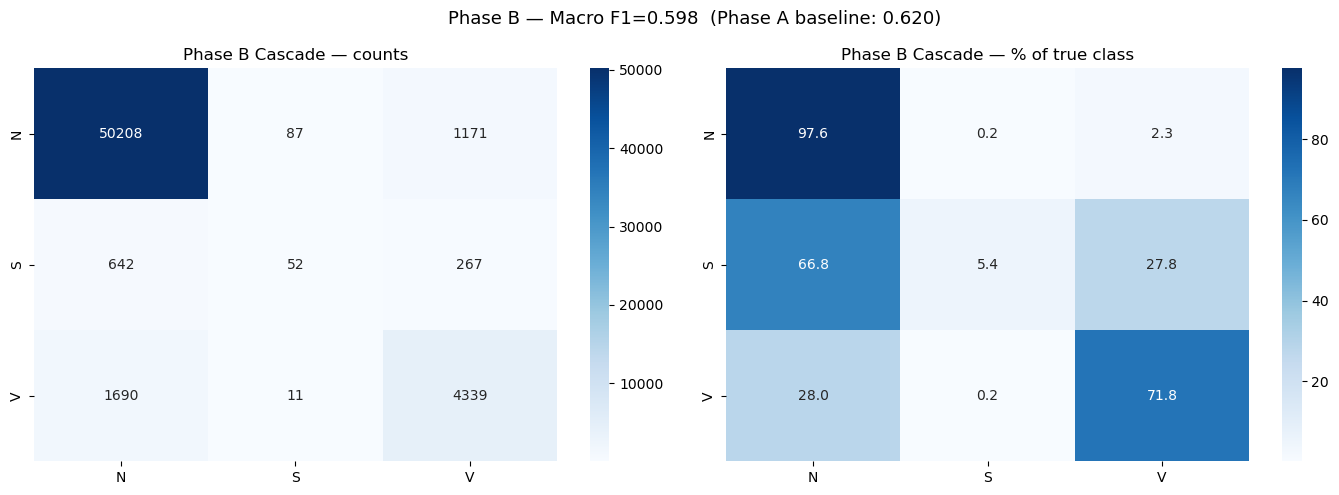

In [17]:
# === Cell 17 — CASCADE EVAL on MIT-BIH test (3-class SV) ==================
print("=" * 60)
print("CASCADE EVAL — MIT-BIH test (Phase B: 3-class SV + INCART-trained Gate)")
print("=" * 60)

full_X_test  = mb_X_test
full_rr_test = normalize_rr(mb_rr_test)
full_y_test  = mb_y_test

# Gate pass
gate_probs_full = gate_model.predict([full_X_test, full_rr_test],
                                      batch_size=128, verbose=0).flatten()
gate_preds_full = (gate_probs_full > best_gate_thr).astype(int)
abn_mask = gate_preds_full == 1

cascade_pred = np.full(len(full_y_test), 'N', dtype=object)
if np.any(abn_mask):
    sv_probs_cascade = sv_model.predict(
        [full_X_test[abn_mask], full_rr_test[abn_mask]],
        batch_size=128, verbose=0
    )  # (n_abn, 3) softmax
    sv_preds_3c = sv_probs_cascade.argmax(axis=1)
    # B2 PATCH: 3-class argmax — can return 'N', 'S', or 'V' (was force S/V in A)
    cascade_pred[abn_mask] = sv_le_3class.inverse_transform(sv_preds_3c)

print(classification_report(full_y_test, cascade_pred, target_names=['N','S','V']))

macro_f1 = f1_score(full_y_test, cascade_pred, average='macro',
                    labels=['N','S','V'], zero_division=0)
per_class = f1_score(full_y_test, cascade_pred, average=None,
                     labels=['N','S','V'], zero_division=0)
print(f"Cascade Macro F1: {macro_f1:.3f}")
for cls, f1_val in zip(['N','S','V'], per_class):
    print(f"  F1 {cls}: {f1_val:.3f}")

# Confusion matrix
cm_cas = confusion_matrix(full_y_test, cascade_pred, labels=['N','S','V'])
cm_pct = cm_cas.astype(float) / cm_cas.sum(axis=1)[:,None] * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_cas, annot=True, fmt='d', cmap='Blues',
            xticklabels=['N','S','V'], yticklabels=['N','S','V'], ax=axes[0])
axes[0].set_title('Phase B Cascade — counts')
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['N','S','V'], yticklabels=['N','S','V'], ax=axes[1])
axes[1].set_title('Phase B Cascade — % of true class')
plt.suptitle(f'Phase B — Macro F1={macro_f1:.3f}  (Phase A baseline: 0.620)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR_PHASE_B}/cascade_confusion_matrix.png', dpi=150)
plt.show()

In [18]:
# === Cell 18 — CROSS-DB EVAL on INCART test split (I51-I75) ===============
print("=" * 60)
print("CROSS-DB EVAL — INCART test split (I51-I75, never trained)")
print("=" * 60)

inc_beats_test, inc_rr_test, inc_labels_test, inc_recs_test = load_records(
    INCART_PATH, INCART_TEST_RECORDS, 'incart_test',
    two_channel=True, source_fs=500
)
inc_rr_test_n = normalize_rr(inc_rr_test)

keep = np.isin(inc_labels_test, ['N', 'S', 'V'])
inc_beats_k  = inc_beats_test[keep]
inc_rr_n_k   = inc_rr_test_n[keep]
inc_labels_k = inc_labels_test[keep]
print(f"INCART test: {len(inc_labels_k):,} N/S/V beats  dist={Counter(inc_labels_k)}")

# Cascade inference with Phase B thresholds
gate_probs_inc = gate_model.predict([inc_beats_k, inc_rr_n_k],
                                     batch_size=128, verbose=0).flatten()
gate_preds_inc = (gate_probs_inc > best_gate_thr).astype(int)
abn_inc = gate_preds_inc == 1

cascade_pred_inc = np.full(len(inc_labels_k), 'N', dtype=object)
if np.any(abn_inc):
    sv_probs_inc = sv_model.predict([inc_beats_k[abn_inc], inc_rr_n_k[abn_inc]],
                                     batch_size=128, verbose=0)
    sv_preds_inc_3c = sv_probs_inc.argmax(axis=1)
    cascade_pred_inc[abn_inc] = sv_le_3class.inverse_transform(sv_preds_inc_3c)

print()
print(classification_report(inc_labels_k, cascade_pred_inc,
                             target_names=['N','S','V'], zero_division=0))

inc_macro = f1_score(inc_labels_k, cascade_pred_inc,
                      average='macro', labels=['N','S','V'], zero_division=0)
inc_per   = f1_score(inc_labels_k, cascade_pred_inc,
                      average=None, labels=['N','S','V'], zero_division=0)

print("=" * 60)
print("CROSS-DB SUMMARY — Phase B vs Phase A")
print("=" * 60)
print(f"                       Phase A      Phase B      Delta")
print(f"  MIT-BIH test macro F1: 0.620        {macro_f1:.3f}        {macro_f1-0.620:+.3f}")
print(f"  INCART      macro F1: 0.413        {inc_macro:.3f}        {inc_macro-0.413:+.3f}")
print(f"  Generalization gap   : 0.207        {macro_f1-inc_macro:.3f}        {(macro_f1-inc_macro)-0.207:+.3f}")
print()
for cls, f1_val_a, f1_val_b in zip(['N','S','V'],
                                     [0.967, 0.123, 0.769],  # Phase A numbers
                                     per_class):
    print(f"  MIT-BIH F1 {cls}:  {f1_val_a:.3f}        {f1_val_b:.3f}        {f1_val_b-f1_val_a:+.3f}")
print()
for cls, f1_val_a, f1_val_b in zip(['N','S','V'],
                                     [0.936, 0.076, 0.227],  # Phase A INCART numbers
                                     inc_per):
    print(f"  INCART  F1 {cls}:  {f1_val_a:.3f}        {f1_val_b:.3f}        {f1_val_b-f1_val_a:+.3f}")

CROSS-DB EVAL — INCART test split (I51-I75, never trained)
  incart_test/I51: 2775 beats  (12ch [CH1=DUP])
  incart_test/I52: 1746 beats  (12ch [CH1=DUP])
  incart_test/I53: 2260 beats  (12ch [CH1=DUP])
  incart_test/I54: 2362 beats  (12ch [CH1=DUP])
  incart_test/I55: 2165 beats  (12ch [CH1=DUP])
  incart_test/I56: 1704 beats  (12ch [CH1=DUP])
  incart_test/I57: 2867 beats  (12ch [CH1=DUP])
  incart_test/I58: 2323 beats  (12ch [CH1=DUP])
  incart_test/I59: 2147 beats  (12ch [CH1=DUP])
  incart_test/I60: 2474 beats  (12ch [CH1=DUP])
  incart_test/I61: 1453 beats  (12ch [CH1=DUP])
  incart_test/I62: 2269 beats  (12ch [CH1=DUP])
  incart_test/I63: 1992 beats  (12ch [CH1=DUP])
  incart_test/I64: 1911 beats  (12ch [CH1=DUP])
  incart_test/I65: 2664 beats  (12ch [CH1=DUP])
  incart_test/I66: 2338 beats  (12ch [CH1=DUP])
  incart_test/I67: 2974 beats  (12ch [CH1=DUP])
  incart_test/I68: 2644 beats  (12ch [CH1=DUP])
  incart_test/I69: 2168 beats  (12ch [CH1=DUP])
  incart_test/I70: 1665 beats

In [19]:
# === Cell 19 — PHASE B SUMMARY ============================================
print("=" * 60)
print("PHASE B SUMMARY — report these numbers back")
print("=" * 60)
print()
print("1. MIT-BIH test (Phase B):")
print(f"   Cascade macro F1 = {macro_f1:.3f}  (Phase A was 0.620)")
print(f"   Per-class: N={per_class[0]:.3f}  S={per_class[1]:.3f}  V={per_class[2]:.3f}")
print(f"   Gate threshold (frozen) = {best_gate_thr}")
print()
print("2. INCART cross-DB (Phase B):")
print(f"   INCART macro F1 = {inc_macro:.3f}  (Phase A was 0.413)")
print(f"   Per-class: N={inc_per[0]:.3f}  S={inc_per[1]:.3f}  V={inc_per[2]:.3f}")
print(f"   Generalization gap = {macro_f1 - inc_macro:.3f}  (Phase A was 0.207)")
print()
print("3. SV routed-population stats:")
print(f"   Gate routed {routed_mask.sum():,} / {len(routed_mask):,} train beats to SV")
print(f"   Routed true-label distribution: {Counter(combined_y_train[routed_mask])}")
print()
print("=" * 60)
print("DECISION TREE for next step:")
print("=" * 60)
if inc_macro > 0.55 and macro_f1 - inc_macro < 0.10:
    print("  ✓ INCART F1 ≥ 0.55 AND gap < 0.10 → Model is clinically credible.")
    print("    Proceed to Phase C (calibration + temporal aggregation).")
elif inc_macro > 0.45:
    print("  ~ INCART F1 in [0.45, 0.55] → Acceptable but augment harder in Phase B4.")
    print("    If time permits: add time-warp + lead-dropout augmentation, retrain SV only.")
else:
    print("  ✗ INCART F1 < 0.45 → Still memorizing. Need stronger intervention.")
    print("    Options: (a) more augmentation, (b) add QTDB to training, (c) lighter model.")
print()
if per_class[1] > 0.40:
    print(f"  ✓ S F1 = {per_class[1]:.3f} ≥ 0.40 → 3-class SV fix worked.")
else:
    print(f"  ✗ S F1 = {per_class[1]:.3f} < 0.40 → 3-class SV didn't fully fix S.")
    print(f"    Likely cause: S is fundamentally hard with current features/architecture.")
    print(f"    Next: Phase C1 temporal aggregation (S as 30s-window AFib detection, not per-beat).")

PHASE B SUMMARY — report these numbers back

1. MIT-BIH test (Phase B):
   Cascade macro F1 = 0.598  (Phase A was 0.620)
   Per-class: N=0.965  S=0.094  V=0.734
   Gate threshold (frozen) = 0.12

2. INCART cross-DB (Phase B):
   INCART macro F1 = 0.617  (Phase A was 0.413)
   Per-class: N=0.987  S=0.025  V=0.838
   Generalization gap = -0.019  (Phase A was 0.207)

3. SV routed-population stats:
   Gate routed 62,410 / 154,908 train beats to SV
   Routed true-label distribution: Counter({'N': 43331, 'V': 15731, 'S': 3348})

DECISION TREE for next step:
  ✓ INCART F1 ≥ 0.55 AND gap < 0.10 → Model is clinically credible.
    Proceed to Phase C (calibration + temporal aggregation).

  ✗ S F1 = 0.094 < 0.40 → 3-class SV didn't fully fix S.
    Likely cause: S is fundamentally hard with current features/architecture.
    Next: Phase C1 temporal aggregation (S as 30s-window AFib detection, not per-beat).


---
## Phase B — what to report back

After running this notebook end-to-end, paste back:

1. **MIT-BIH test macro F1** + per-class N/S/V
2. **INCART macro F1** + per-class N/S/V
3. **Generalization gap** (MIT-BIH − INCART)
4. **SV routed-population stats** (what % Gate routed, true-label distribution)

## Expected outcomes

Based on Phase A results, expected Phase B outcomes:

| Metric | Phase A | Expected Phase B | Why |
|--------|---------|------------------|-----|
| MIT-BIH macro F1 | 0.620 | **0.70–0.78** | 3-class SV fixes S precision crater |
| MIT-BIH S F1 | 0.123 | **0.40–0.55** | SV can finally reject Gate false positives |
| INCART macro F1 | 0.413 | **0.55–0.65** | V now sees INCART-like data in training |
| INCART V F1 | 0.227 | **0.50–0.65** | V morphology no longer MIT-BIH-specific |
| Generalization gap | 0.207 | **0.08–0.15** | INCART in train closes the gap |

If S F1 still < 0.40 after this, we move to **Phase C1 (temporal aggregation)** — stop trying to classify S per-beat, instead detect AFib as a 30s-window event (which is what the clinical definition actually says). That's the clinically correct fallback.

## If you have time after Phase B

The notebook leaves room for:
- **Phase C1**: Temporal aggregation for AFib (30s window logic in firmware)
- **Phase C2**: Temperature-scaling calibration
- **Phase D**: Firmware integration (ring buffer + `tarang_ai_process()`)

But run Phase B first, see the numbers, then decide.